<a href="https://colab.research.google.com/github/krishshah8000/mlproject/blob/master/House_Prediction_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Bengaluru_House_Data.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [ ]:
num_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicates}')

if num_duplicates > 0:
    display(df[df.duplicated(keep=False)].head())
else:
    print('No duplicate rows found.')

Number of duplicate rows: 529


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
33,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,3 BHK,GrrvaGr,1693,3.0,3.0,57.39
35,Super built-up Area,21-Dec,Kanakpura Road,2 BHK,PrarePa,700,2.0,1.0,36.00
38,Super built-up Area,Ready To Move,Chikkalasandra,3 BHK,NaN,1290,2.0,2.0,56.12
55,Super built-up Area,Ready To Move,Begur Road,2 BHK,Dhalsh,1200,2.0,2.0,44.00


In [ ]:
df = df.drop_duplicates()
print(f'Duplicate rows removed. New shape: {df.shape}')
display(df.head())

Duplicate rows removed. New shape: (12791, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
null_counts = df.isnull().sum()
print("Null values per column:")
display(null_counts)

Null values per column:


,0
area_type,0
availability,0
location,1
size,16
society,5328
total_sqft,0
bath,73
balcony,605
price,0


In [ ]:
df.drop(columns=['society'], inplace=True)
print('Society column dropped.')
display(df.head())

Society column dropped.


/tmp/ipython-input-3380316175.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['society'], inplace=True)


,area_type,availability,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [ ]:
location_mode = df['location'].mode()[0]
df['location'] = df['location'].fillna(location_mode)
print(f"Filled missing location with mode: {location_mode}")
print(f"Remaining nulls in location: {df['location'].isnull().sum()}")

Filled missing location with mode: Whitefield
Remaining nulls in location: 0


/tmp/ipython-input-2092404206.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['location'] = df['location'].fillna(location_mode)


In [ ]:
for col in df.columns:
    print(f"Unique values in {col}: {df[col].nunique()}")
    display(df[col].unique())

Unique values in area_type: 4


array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

Unique values in availability: 81


array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr', '16-Jan', '14-Jul'], dtype=object)

Unique values in location: 1305


...

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9., nan,  8.,  7., 11., 10., 14.,
       27., 12., 16., 40., 15., 13., 18.])

Unique values in balcony: 4


array([ 1.,  3., nan,  2.,  0.])

Unique values in price: 1994


array([ 39.07, 120.  ,  62.  , ...,  40.14, 231.  , 488.  ])

In [ ]:
ready_to_move_count = df[df['availability'] == 'Ready To Move'].shape[0]
immediate_possession_count = df[df['availability'] == 'Immediate Possession'].shape[0]

print(f"'Ready To Move' count: {ready_to_move_count}")
print(f"'Immediate Possession' count: {immediate_possession_count}")

'Ready To Move' count: 10172
'Immediate Possession' count: 16


In [ ]:
df['availability'] = df['availability'].replace('Immediate Possession', 'Ready To Move')
print("Value counts for availability:")
print(df['availability'].value_counts()[['Ready To Move']])

Value counts for availability:
availability
Ready To Move    10188
Name: count, dtype: int64


/tmp/ipython-input-1410531777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['availability'] = df['availability'].replace('Immediate Possession', 'Ready To Move')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12791 non-null  object 
 1   availability  12791 non-null  object 
 2   location      12791 non-null  object 
 3   size          12775 non-null  object 
 4   total_sqft    12791 non-null  object 
 5   bath          12718 non-null  float64
 6   balcony       12186 non-null  float64
 7   price         12791 non-null  float64
dtypes: float64(3), object(5)
memory usage: 899.4+ KB


In [ ]:
import pandas as pd

# Check if 'size' exists. If it does, transform and rename it to 'bhk'.
# If 'bhk' already exists and 'size' is gone, we are already done.
if 'size' in df.columns:
    if 'bhk' in df.columns:
        df = df.drop(columns=['bhk'])
    df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]) if pd.notnull(x) else x).astype('Int64')
    df.drop(columns=['size'], inplace=True)
    print('Column cleaned and renamed to bhk.')
else:
    print("Column 'size' not found. It might have already been renamed to 'bhk'.")

display(df.info())
display(df.head())

Column cleaned and renamed to bhk.
<class 'pandas.core.frame.DataFrame'>
Index: 12791 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12791 non-null  object 
 1   availability  12791 non-null  object 
 2   location      12791 non-null  object 
 3   total_sqft    12791 non-null  object 
 4   bath          12718 non-null  float64
 5   balcony       12186 non-null  float64
 6   price         12791 non-null  float64
 7   bhk           12775 non-null  Int64  
dtypes: Int64(1), float64(3), object(4)
memory usage: 911.9+ KB


/tmp/ipython-input-2919671672.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]) if pd.notnull(x) else x).astype('Int64')
/tmp/ipython-input-2919671672.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['size'], inplace=True)


None

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


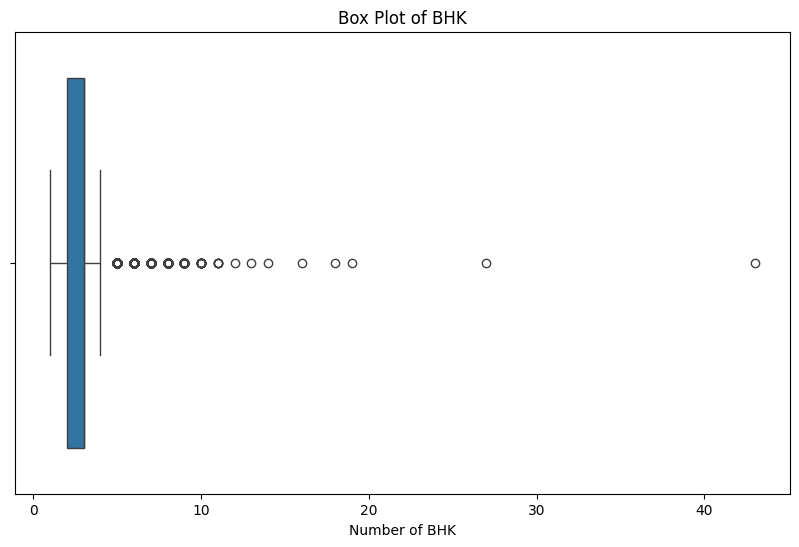

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['bhk'].dropna().astype(float))
plt.title('Box Plot of BHK')
plt.xlabel('Number of BHK')
plt.show()

In [ ]:
df = df[~(df['bhk'] > 20)]
print(f"Rows with more than 20 BHK removed. New shape: {df.shape}")
print("Maximum BHK now in dataset:", df['bhk'].max())
display(df.head())

Rows with more than 20 BHK removed. New shape: (12773, 8)
Maximum BHK now in dataset: 19


,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


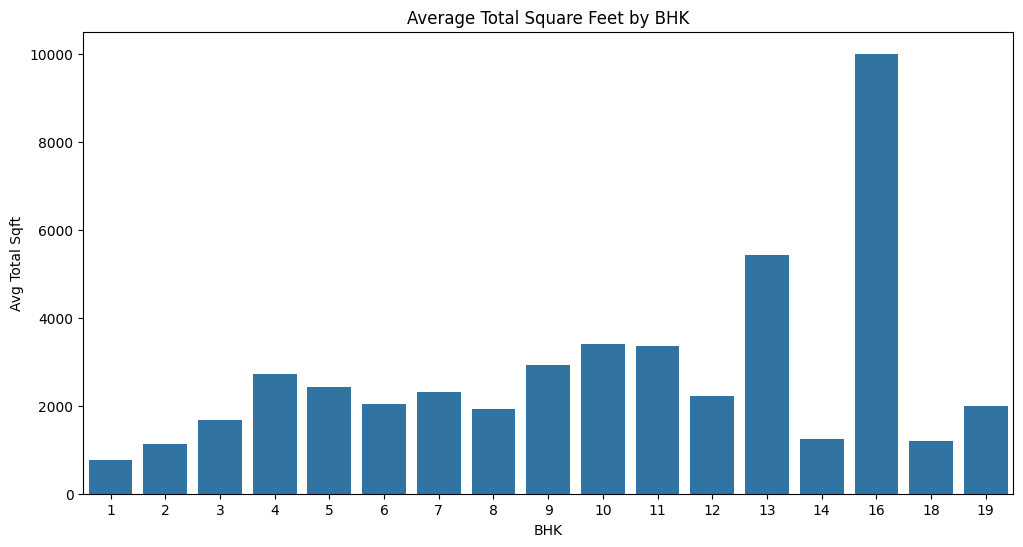

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

# Create a copy to avoid SettingWithCopyWarning
df_plot = df.copy()
df_plot['total_sqft'] = df_plot['total_sqft'].apply(convert_sqft_to_num)

# Grouping and plotting
avg_sqft = df_plot.groupby('bhk')['total_sqft'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_sqft, x='bhk', y='total_sqft')
plt.title('Average Total Square Feet by BHK')
plt.xlabel('BHK')
plt.ylabel('Avg Total Sqft')
plt.show()

In [ ]:
df = df[df['bhk'] < 14]
print(f'Removed rows with 14 or more BHK. New shape: {df.shape}')
print(f'New maximum BHK: {df["bhk"].max()}')
display(df.head())

Removed rows with 14 or more BHK. New shape: (12769, 8)
New maximum BHK: 13


,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


In [ ]:
def convert_sqft_to_num(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

# Apply the conversion to the total_sqft column
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

print('Total square feet ranges converted to averages.')
print(f"Remaining nulls in total_sqft: {df['total_sqft'].isnull().sum()}")
display(df.head())

Total square feet ranges converted to averages.
Remaining nulls in total_sqft: 46


,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200.0,2.0,1.0,51.00,2


In [ ]:
import numpy as np
import pandas as pd

# Calculate the floor and convert to nullable Int64
df['total_sqft'] = df['total_sqft'].apply(lambda x: int(np.floor(x)) if pd.notnull(x) else x).astype('Int64')

print('Converted total_sqft to floor integers.')
display(df.info())
display(df.head())

Converted total_sqft to floor integers.
<class 'pandas.core.frame.DataFrame'>
Index: 12769 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12769 non-null  object 
 1   availability  12769 non-null  object 
 2   location      12769 non-null  object 
 3   total_sqft    12723 non-null  Int64  
 4   bath          12712 non-null  float64
 5   balcony       12183 non-null  float64
 6   price         12769 non-null  float64
 7   bhk           12769 non-null  Int64  
dtypes: Int64(2), float64(3), object(3)
memory usage: 922.8+ KB


None

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


In [ ]:
bhk_mode = df['bhk'].mode()[0]
df['bhk'] = df['bhk'].fillna(bhk_mode)
print(f"Filled missing BHK with mode: {bhk_mode}")
print(f"Remaining nulls in bhk: {df['bhk'].isnull().sum()}")
display(df.info())

Filled missing BHK with mode: 2
Remaining nulls in bhk: 0
<class 'pandas.core.frame.DataFrame'>
Index: 12769 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12769 non-null  object 
 1   availability  12769 non-null  object 
 2   location      12769 non-null  object 
 3   total_sqft    12723 non-null  Int64  
 4   bath          12712 non-null  float64
 5   balcony       12183 non-null  float64
 6   price         12769 non-null  float64
 7   bhk           12769 non-null  Int64  
dtypes: Int64(2), float64(3), object(3)
memory usage: 922.8+ KB


None

In [ ]:
# Filter rows where balcony is null
balcony_null_df = df[df['balcony'].isnull()]

# Count BHK values for these rows
bhk_counts_for_null_balcony = balcony_null_df['bhk'].value_counts().sort_index()

print("Distribution of BHK for rows where balcony is null:")
display(bhk_counts_for_null_balcony)

Distribution of BHK for rows where balcony is null:


,count
bhk,
1,8
2,48
3,199
4,177
5,57
6,29
7,15
8,21
9,20


In [ ]:
import pandas as pd

# Function to calculate mode of a series, handling cases where it might be empty
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else 0

# Calculate the mode for each BHK group
bhk_balcony_modes = df.groupby('bhk')['balcony'].apply(get_mode)

# Fill nulls by mapping the bhk_balcony_modes back to the dataframe
def fill_balcony(row):
    if pd.isnull(row['balcony']):
        return bhk_balcony_modes.get(row['bhk'], 0)
    return row['balcony']

df['balcony'] = df.apply(fill_balcony, axis=1)

print('Missing balcony values filled based on the mode of their respective BHK groups.')
print(f"Remaining nulls in balcony: {df['balcony'].isnull().sum()}")
display(df.info())
display(df.head())

Missing balcony values filled based on the mode of their respective BHK groups.
Remaining nulls in balcony: 0
<class 'pandas.core.frame.DataFrame'>
Index: 12769 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12769 non-null  object 
 1   availability  12769 non-null  object 
 2   location      12769 non-null  object 
 3   total_sqft    12723 non-null  Int64  
 4   bath          12712 non-null  float64
 5   balcony       12769 non-null  float64
 6   price         12769 non-null  float64
 7   bhk           12769 non-null  Int64  
dtypes: Int64(2), float64(3), object(3)
memory usage: 922.8+ KB


None

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


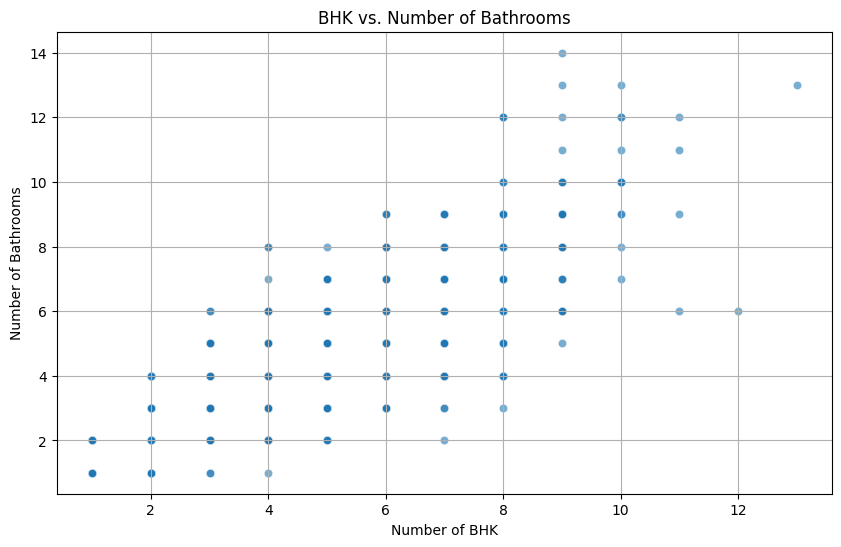

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bhk', y='bath', data=df, alpha=0.6)
plt.title('BHK vs. Number of Bathrooms')
plt.xlabel('Number of BHK')
plt.ylabel('Number of Bathrooms')
plt.grid(True)
plt.show()

In [ ]:
df.loc[df['bath'] > df['bhk'], 'bath'] = df['bhk'] + 1
display(df.head())

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


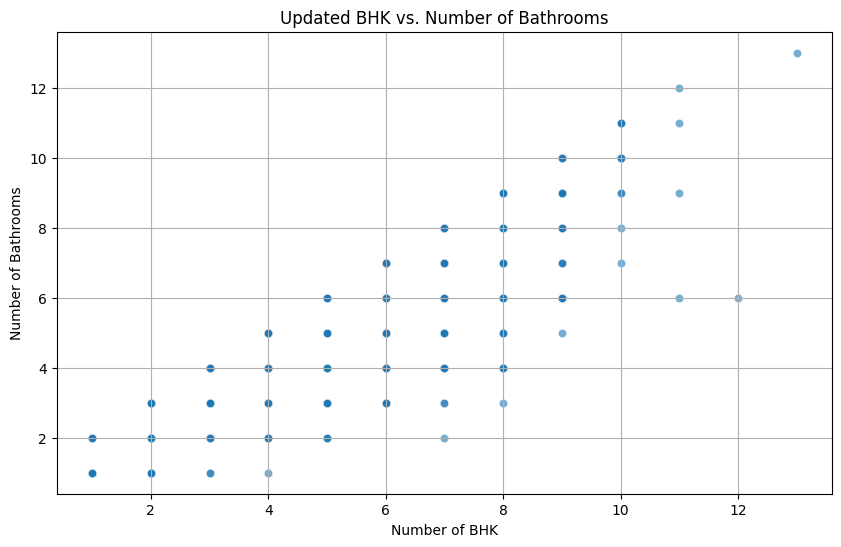

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='bhk', y='bath', data=df, alpha=0.6)
plt.title('Updated BHK vs. Number of Bathrooms')
plt.xlabel('Number of BHK')
plt.ylabel('Number of Bathrooms')
plt.grid(True)
plt.show()

In [ ]:
df['bath'] = df['bath'].fillna(df['bhk'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12769 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12769 non-null  object 
 1   availability  12769 non-null  object 
 2   location      12769 non-null  object 
 3   total_sqft    12723 non-null  Int64  
 4   bath          12769 non-null  float64
 5   balcony       12769 non-null  float64
 6   price         12769 non-null  float64
 7   bhk           12769 non-null  Int64  
dtypes: Int64(2), float64(3), object(3)
memory usage: 1.4+ MB


In [ ]:
null_summary = df.isnull().sum()
print('Missing values in each column:')
display(null_summary)

Missing values in each column:


,0
area_type,0
availability,0
location,0
total_sqft,46
bath,0
balcony,0
price,0
bhk,0


In [ ]:
df = df.dropna(subset=['total_sqft'])
print(f'Final null values removed. New shape: {df.shape}')
print('\nMissing values summary:')
display(df.isnull().sum())

Final null values removed. New shape: (12723, 8)

Missing values summary:


,0
area_type,0
availability,0
location,0
total_sqft,0
bath,0
balcony,0
price,0
bhk,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12723 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12723 non-null  object 
 1   availability  12723 non-null  object 
 2   location      12723 non-null  object 
 3   total_sqft    12723 non-null  Int64  
 4   bath          12723 non-null  float64
 5   balcony       12723 non-null  float64
 6   price         12723 non-null  float64
 7   bhk           12723 non-null  Int64  
dtypes: Int64(2), float64(3), object(3)
memory usage: 919.4+ KB


In [ ]:
import datetime

def clean_availability(x):
    if x in ['Ready To Move']:
        return 'Ready To Move'
    try:
        # If it's a date → Under Construction
        return 'Under Construction'
    except:
        return 'Other'

df['availability'] = df['availability'].apply(clean_availability)


In [ ]:
df.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Under Construction,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


In [ ]:
# Check unique values in the availability column
unique_availability = df['availability'].unique()
print("Unique values in 'availability':")
print(unique_availability)

Unique values in 'availability':
['Under Construction' 'Ready To Move']


In [ ]:
availability_mapping = {'Under Construction': 0, 'Ready To Move': 1}
df['availability'] = df['availability'].map(availability_mapping)

print('Mapped availability values to numeric.')
display(df['availability'].value_counts())
display(df.head())

Mapped availability values to numeric.


,count
availability,
1,10128
0,2595


,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,1,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,1,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,1,Kothanur,1200,2.0,1.0,51.00,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12723 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12723 non-null  object 
 1   availability  12723 non-null  int64  
 2   location      12723 non-null  object 
 3   total_sqft    12723 non-null  Int64  
 4   bath          12723 non-null  float64
 5   balcony       12723 non-null  float64
 6   price         12723 non-null  float64
 7   bhk           12723 non-null  Int64  
dtypes: Int64(2), float64(3), int64(1), object(2)
memory usage: 919.4+ KB


In [ ]:
location_price = df.groupby('location')['price'].mean()
df['location'] = df['location'].map(location_price)

In [ ]:
area_type_dummies = pd.get_dummies(df['area_type'], prefix='area_type', dtype=int)
df = pd.concat([df, area_type_dummies], axis=1)
df = df.drop('area_type', axis='columns')
display(df.head())

,availability,location,total_sqft,bath,balcony,price,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,0,48.683906,1056,2.0,1.0,39.07,2,0,0,0,1
1,1,114.704375,2600,5.0,3.0,120.00,4,0,0,1,0
2,1,63.268535,1440,2.0,3.0,62.00,3,1,0,0,0
3,1,115.348261,1521,3.0,1.0,95.00,3,0,0,0,1
4,1,95.790625,1200,2.0,1.0,51.00,2,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop('price', axis=1)
y = df['price']

print(f'Shape of X: {X.shape}')
print(f'Shape of y: {y.shape}')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X: (12723, 10)
Shape of y: (12723,)
Shape of X_train: (10178, 10)
Shape of X_test: (2545, 10)
Shape of y_train: (10178,)
Shape of y_test: (2545,)


## Apply Scaling and Normalization



In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Instantiate StandardScaler for features
feature_scaler_standard = StandardScaler()

# Apply StandardScaler to 'location' and 'total_sqft' columns
X_train[['location', 'total_sqft']] = feature_scaler_standard.fit_transform(X_train[['location', 'total_sqft']])
X_test[['location', 'total_sqft']] = feature_scaler_standard.transform(X_test[['location', 'total_sqft']])

# Instantiate MinMaxScaler for other features
feature_scaler_minmax = MinMaxScaler()

# Apply MinMaxScaler to 'bath', 'balcony', and 'bhk' columns
X_train[['bath', 'balcony', 'bhk']] = feature_scaler_minmax.fit_transform(X_train[['bath', 'balcony', 'bhk']])
X_test[['bath', 'balcony', 'bhk']] = feature_scaler_minmax.transform(X_test[['bath', 'balcony', 'bhk']])

# Instantiate a separate StandardScaler for the target variable 'price'
target_scaler = StandardScaler()

# Fit and transform y_train and transform y_test
y_train = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test = target_scaler.transform(y_test.values.reshape(-1, 1))

print("Features and target variable scaled successfully.")
print("X_train head after scaling:")
display(X_train.head())
print("y_train head after scaling:")
display(y_train[:5])


Features and target variable scaled successfully.
X_train head after scaling:


,availability,location,total_sqft,bath,balcony,bhk,area_type_Built-up Area,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
1017,1,-0.801925,-0.129630,0.083333,0.000000,0.083333,0,0,1,0
5498,1,-0.801925,0.247414,0.250000,0.666667,0.250000,1,0,0,0
3529,1,-0.498653,-0.329286,0.083333,0.666667,0.083333,0,0,0,1
10351,0,-0.193652,-0.734742,0.000000,0.000000,0.000000,0,0,0,1
13234,1,-0.104605,-0.029801,0.083333,0.333333,0.083333,0,0,0,1


y_train head after scaling:


array([[-0.35033258],
       [-0.31054601],
       [-0.48876274],
       [-0.55965576],
       [-0.0405588 ]])

## Train and Evaluate Linear Regression


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Instantiate Linear Regression model
linear_reg_model = LinearRegression()

# Train the model
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

# Make predictions on the scaled test data
y_pred = linear_reg_model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Linear Regression model trained successfully.

Mean Squared Error (MSE): 0.2835
Root Mean Squared Error (RMSE): 0.5325
R-squared (R2): 0.6356


## Hyperparameter Tuning and Evaluation for Random Forest




In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Instantiate RandomForestRegressor model
rf = RandomForestRegressor(random_state=42)

# 2. Define the hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2'], # Removed 'auto'
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Instantiate RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid_rf,
    n_iter=10, # Number of random combinations to try
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# 4. Fit RandomizedSearchCV to the scaled training data
random_search_rf.fit(X_train, y_train.ravel()) # .ravel() to convert y_train to 1D array

print("RandomizedSearchCV completed.")

# 5. Retrieve the best estimator
best_rf_model = random_search_rf.best_estimator_
print(f"Best Random Forest parameters: {random_search_rf.best_params_}")

# 6. Make predictions on the scaled test data
y_pred_rf = best_rf_model.predict(X_test)

# 7. Calculate evaluation metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Regressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomizedSearchCV completed.
Best Random Forest parameters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 50}

Random Forest Regressor Evaluation Metrics:
Mean Squared Error (MSE): 0.1575
Root Mean Squared Error (RMSE): 0.3968
R-squared (R2): 0.7976


## Hyperparameter Tuning and Evaluation for XGBoost



In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Instantiate XGBRegressor model
xgb = XGBRegressor(random_state=42)

# 2. Define the hyperparameter grid
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, 12],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

# 3. Instantiate RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=10, # Number of random combinations to try
    cv=5, # 5-fold cross-validation
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# 4. Fit RandomizedSearchCV to the scaled training data
random_search_xgb.fit(X_train, y_train.ravel()) # .ravel() to convert y_train to 1D array

print("RandomizedSearchCV for XGBoost completed.")

# 5. Retrieve the best estimator
best_xgb_model = random_search_xgb.best_estimator_
print(f"Best XGBoost parameters: {random_search_xgb.best_params_}")

# 6. Make predictions on the scaled test data
y_pred_xgb = best_xgb_model.predict(X_test)

# 7. Calculate evaluation metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Regressor Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
RandomizedSearchCV for XGBoost completed.
Best XGBoost parameters: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 1.0}

XGBoost Regressor Evaluation Metrics:
Mean Squared Error (MSE): 0.1447
Root Mean Squared Error (RMSE): 0.3804
R-squared (R2): 0.8140


## Summary:


*   **Linear Regression Model Performance**:
    *   Mean Squared Error (MSE): 0.2835
    *   Root Mean Squared Error (RMSE): 0.5325
    *   R-squared (R2): 0.6356
*   **Random Forest Regressor Model Performance (after hyperparameter tuning)**:
    *   The best hyperparameters found were `n_estimators=400`, `min_samples_split=5`, `min_samples_leaf=2`, `max_features='sqrt'`, and `max_depth=50`.
    *   Mean Squared Error (MSE): 0.1575
    *   Root Mean Squared Error (RMSE): 0.3968
    *   R-squared (R2): 0.7976
*   **XGBoost Regressor Model Performance (after hyperparameter tuning)**:
    *   The best hyperparameters found were `subsample=1.0`, `n_estimators=100`, `max_depth=5`, `learning_rate=0.05`, `gamma=0.2`, and `colsample_bytree=1.0`.
    *   Mean Squared Error (MSE): 0.1447
    *   Root Mean Squared Error (RMSE): 0.3804
    *   R-squared (R2): 0.8140
*   **Model Comparison**: The XGBoost Regressor demonstrated the best performance among the three models, achieving the lowest MSE (0.1447) and RMSE (0.3804), and the highest R-squared (0.8140). This indicates it explains the most variance in the target variable and has the lowest prediction error.

### Insights or Next Steps

*   **Insight**: Tree-based ensemble models (Random Forest and XGBoost) significantly outperformed the Linear Regression model, indicating that non-linear relationships and interactions between features are crucial for accurate house price prediction in this dataset. XGBoost achieved the best balance of bias and variance after tuning, leading to superior predictive power.
*   **Next Steps**: Further optimization of the XGBoost model could be explored using more extensive hyperparameter tuning (e.g., a wider search space or Bayesian optimization), or by investigating feature engineering techniques to create more informative predictors, potentially improving model performance even further.
